Running vectorized expected-bias grid search for odd degrees...


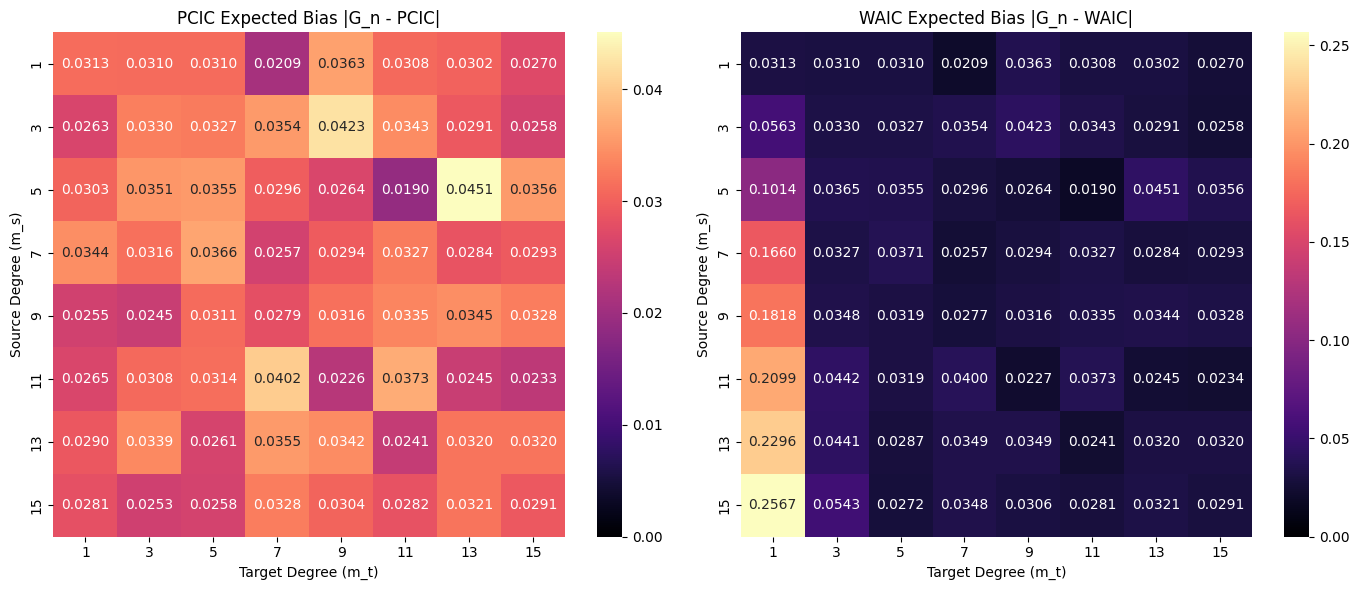

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.special import logsumexp

def compute_expected_bias_vectorized(m_s, m_t, n_trials=30, n_train=400, n_test=2000):
    """
    Vectorized computation of expected bias across multiple independent datasets.
    This smooths out finite-sample noise to reveal the true asymptotic behavior.
    """
    np.random.seed(42 + m_s + 20 * m_t) # Ensure reproducibility but variance across cells
    
    # 1. Generate multiple datasets simultaneously
    X_train = np.random.normal(0, 1, (n_trials, n_train))
    X_test = np.random.normal(0, 1, (n_trials, n_test))
    
    # 2. Grid Approximation
    theta = np.linspace(-1.5, 1.5, 1000)
    
    # Pure analytic polynomials
    theta_s = theta ** m_s
    theta_t = theta ** m_t
    
    # 3. Source Posteriors
    # log_s_train shape: (n_trials, n_train, n_theta)
    log_s_train = -0.5 * ((X_train[:, :, None] - theta_s[None, None, :])**2) - 0.5 * np.log(2 * np.pi)
    log_post = np.sum(log_s_train, axis=1) 
    log_post -= logsumexp(log_post, axis=1, keepdims=True)
    post_probs = np.exp(log_post)
    
    # 4. Target Log-Likelihoods
    log_h_train = -0.5 * ((X_train[:, :, None] - theta_t[None, None, :])**2) - 0.5 * np.log(2 * np.pi)
    log_h_test = -0.5 * ((X_test[:, :, None] - theta_t[None, None, :])**2) - 0.5 * np.log(2 * np.pi)
    
    # 5. Errors
    log_E_h_train = logsumexp(log_h_train + log_post[:, None, :], axis=2)
    log_E_h_test = logsumexp(log_h_test + log_post[:, None, :], axis=2)
    
    T_n = -np.mean(log_E_h_train, axis=1)
    G_n = -np.mean(log_E_h_test, axis=1)
    
    # 6. Penalties via Expected Values
    E_log_h_train = np.sum(log_h_train * post_probs[:, None, :], axis=2)
    E_s_train = np.sum(log_s_train * post_probs[:, None, :], axis=2)
    E_log_h_s_train = np.sum(log_h_train * log_s_train * post_probs[:, None, :], axis=2)
    
    pcic_pen = np.mean(E_log_h_s_train - E_log_h_train * E_s_train, axis=1)
    E_log_h_sq_train = np.sum((log_h_train**2) * post_probs[:, None, :], axis=2)
    waic_pen = np.mean(E_log_h_sq_train - E_log_h_train**2, axis=1)
    
    PCIC = T_n + pcic_pen
    WAIC = T_n + waic_pen
    
    # Return the expected absolute bias averaged over all trials
    return np.mean(np.abs(PCIC - G_n)), np.mean(np.abs(WAIC - G_n))

# --- Run the Grid Experiment ---
odd_degrees = [1, 3, 5, 7, 9, 11, 13, 15]
n_deg = len(odd_degrees)

pcic_biases = np.zeros((n_deg, n_deg))
waic_biases = np.zeros((n_deg, n_deg))
constraint_mask = np.zeros((n_deg, n_deg), dtype=bool)

print("Running vectorized expected-bias grid search for odd degrees...")

for i, m_s in enumerate(odd_degrees):
    for j, m_t in enumerate(odd_degrees):
        p_bias, w_bias = compute_expected_bias_vectorized(m_s, m_t)
        pcic_biases[i, j] = p_bias
        waic_biases[i, j] = w_bias
        constraint_mask[i, j] = (2 * m_s < 3 * m_t)

# --- Plotting ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

kwargs = dict(
    xticklabels=odd_degrees, yticklabels=odd_degrees, 
    annot=True, fmt=".4f", cmap="magma", vmin=0
)

sns.heatmap(pcic_biases, ax=axes[0], **kwargs)
axes[0].set_title("PCIC Expected Bias |G_n - PCIC|")
axes[0].set_xlabel("Target Degree (m_t)")
axes[0].set_ylabel("Source Degree (m_s)")

sns.heatmap(waic_biases, ax=axes[1], **kwargs)
axes[1].set_title("WAIC Expected Bias |G_n - WAIC|")
axes[1].set_xlabel("Target Degree (m_t)")
axes[1].set_ylabel("Source Degree (m_s)")

plt.tight_layout()
plt.show()

Running vectorized expected-bias grid search for odd degrees...


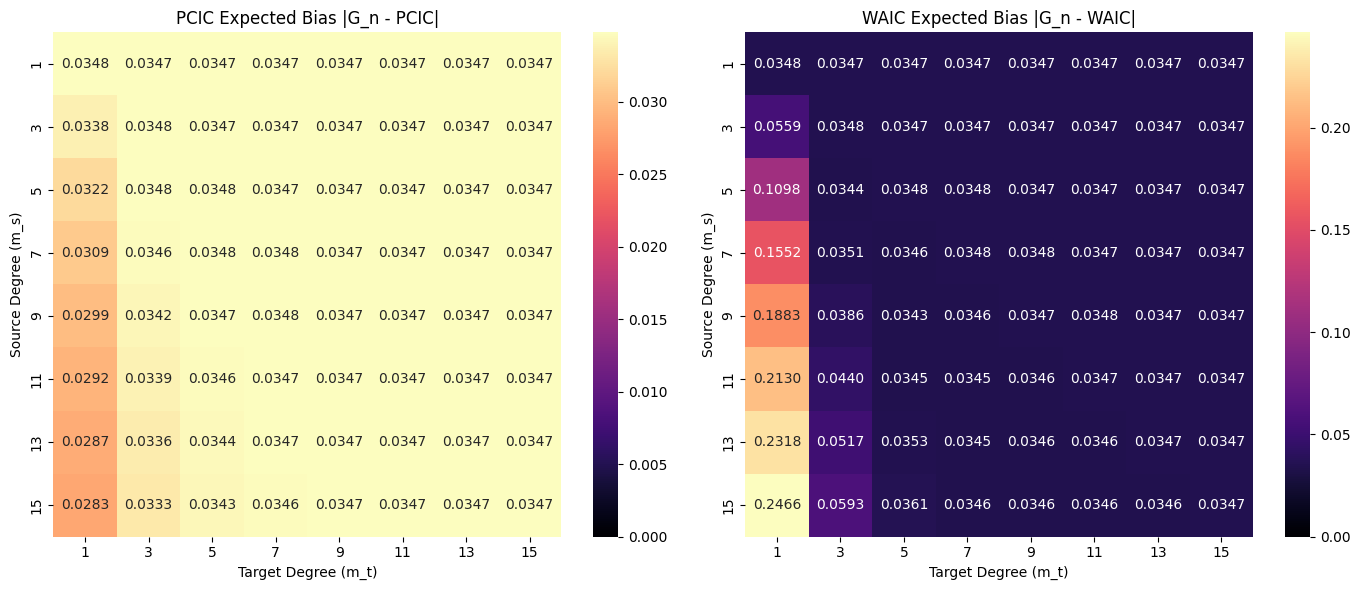

In [2]:
# same as above except with a fixed seed throughout!
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.special import logsumexp

def compute_expected_bias_vectorized(m_s, m_t, n_trials=30, n_train=400, n_test=2000):
    """
    Vectorized computation of expected bias across multiple independent datasets.
    This smooths out finite-sample noise to reveal the true asymptotic behavior.
    """
    np.random.seed(42) # no variance across cells
    
    # 1. Generate multiple datasets simultaneously
    X_train = np.random.normal(0, 1, (n_trials, n_train))
    X_test = np.random.normal(0, 1, (n_trials, n_test))
    
    # 2. Grid Approximation
    theta = np.linspace(-1.5, 1.5, 1000)
    
    # Pure analytic polynomials
    theta_s = theta ** m_s
    theta_t = theta ** m_t
    
    # 3. Source Posteriors
    # log_s_train shape: (n_trials, n_train, n_theta)
    log_s_train = -0.5 * ((X_train[:, :, None] - theta_s[None, None, :])**2) - 0.5 * np.log(2 * np.pi)
    log_post = np.sum(log_s_train, axis=1) 
    log_post -= logsumexp(log_post, axis=1, keepdims=True)
    post_probs = np.exp(log_post)
    
    # 4. Target Log-Likelihoods
    log_h_train = -0.5 * ((X_train[:, :, None] - theta_t[None, None, :])**2) - 0.5 * np.log(2 * np.pi)
    log_h_test = -0.5 * ((X_test[:, :, None] - theta_t[None, None, :])**2) - 0.5 * np.log(2 * np.pi)
    
    # 5. Errors
    log_E_h_train = logsumexp(log_h_train + log_post[:, None, :], axis=2)
    log_E_h_test = logsumexp(log_h_test + log_post[:, None, :], axis=2)
    
    T_n = -np.mean(log_E_h_train, axis=1)
    G_n = -np.mean(log_E_h_test, axis=1)
    
    # 6. Penalties via Expected Values
    E_log_h_train = np.sum(log_h_train * post_probs[:, None, :], axis=2)
    E_s_train = np.sum(log_s_train * post_probs[:, None, :], axis=2)
    E_log_h_s_train = np.sum(log_h_train * log_s_train * post_probs[:, None, :], axis=2)
    
    pcic_pen = np.mean(E_log_h_s_train - E_log_h_train * E_s_train, axis=1)
    E_log_h_sq_train = np.sum((log_h_train**2) * post_probs[:, None, :], axis=2)
    waic_pen = np.mean(E_log_h_sq_train - E_log_h_train**2, axis=1)
    
    PCIC = T_n + pcic_pen
    WAIC = T_n + waic_pen
    
    # Return the expected absolute bias averaged over all trials
    return np.mean(np.abs(PCIC - G_n)), np.mean(np.abs(WAIC - G_n))

# --- Run the Grid Experiment ---
odd_degrees = [1, 3, 5, 7, 9, 11, 13, 15]
n_deg = len(odd_degrees)

pcic_biases = np.zeros((n_deg, n_deg))
waic_biases = np.zeros((n_deg, n_deg))
constraint_mask = np.zeros((n_deg, n_deg), dtype=bool)

print("Running vectorized expected-bias grid search for odd degrees...")

for i, m_s in enumerate(odd_degrees):
    for j, m_t in enumerate(odd_degrees):
        p_bias, w_bias = compute_expected_bias_vectorized(m_s, m_t)
        pcic_biases[i, j] = p_bias
        waic_biases[i, j] = w_bias
        constraint_mask[i, j] = (2 * m_s < 3 * m_t)

# --- Plotting ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

kwargs = dict(
    xticklabels=odd_degrees, yticklabels=odd_degrees, 
    annot=True, fmt=".4f", cmap="magma", vmin=0
)

sns.heatmap(pcic_biases, ax=axes[0], **kwargs)
axes[0].set_title("PCIC Expected Bias |G_n - PCIC|")
axes[0].set_xlabel("Target Degree (m_t)")
axes[0].set_ylabel("Source Degree (m_s)")

sns.heatmap(waic_biases, ax=axes[1], **kwargs)
axes[1].set_title("WAIC Expected Bias |G_n - WAIC|")
axes[1].set_xlabel("Target Degree (m_t)")
axes[1].set_ylabel("Source Degree (m_s)")

plt.tight_layout()
plt.show()

Running grid search with skewed true distribution...


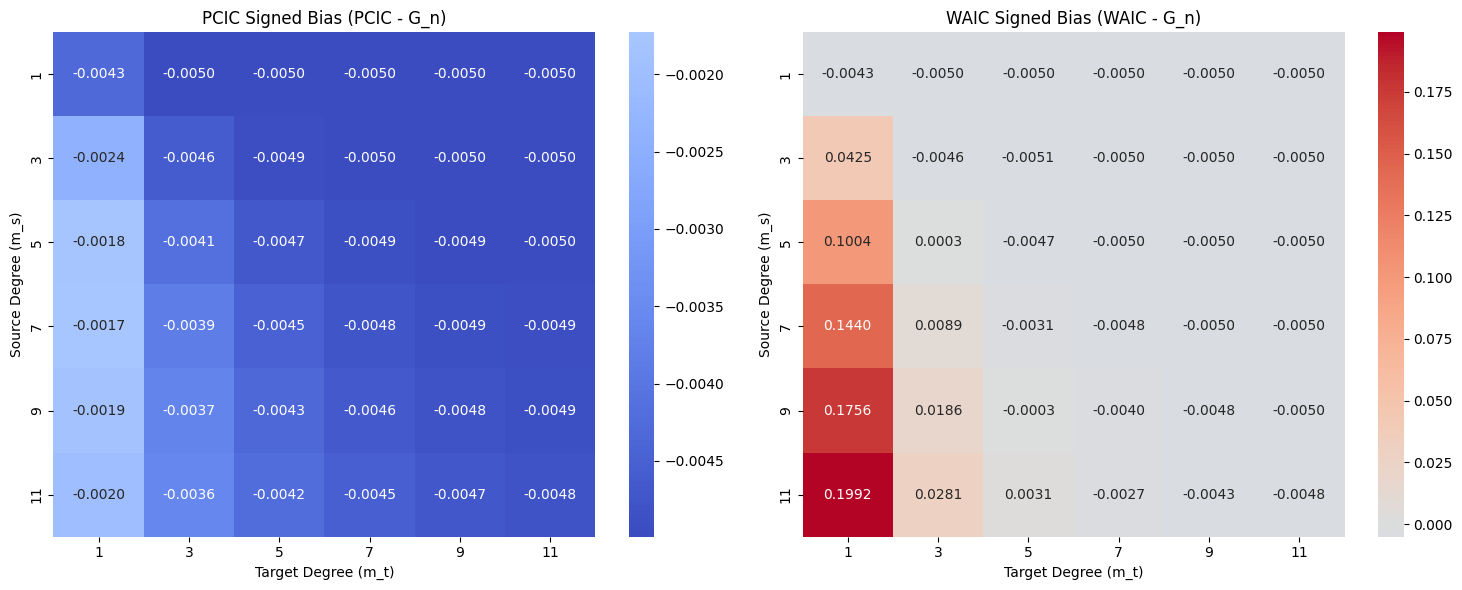

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.special import logsumexp

def compute_signed_bias_vectorized(m_s, m_t, n_trials=30, n_train=500, n_test=2000):
    """
    Computes the signed expected bias using a centered Exponential distribution
    to introduce skewness and prevent the 3rd cumulant from vanishing.
    """
    np.random.seed(42)# + m_s + m_t)
    
    # 1. Generate Skewed True Data (Centered Exponential: Mean=0, Var=1, Skew=2)
    X_train = np.random.exponential(scale=1.0, size=(n_trials, n_train)) - 1.0
    X_test = np.random.exponential(scale=1.0, size=(n_trials, n_test)) - 1.0
    
    # 2. Grid Approximation
    theta = np.linspace(-1.5, 1.5, 1000)
    theta_s = theta ** m_s
    theta_t = theta ** m_t
    
    # 3. Source Posteriors
    log_s_train = -0.5 * ((X_train[:, :, None] - theta_s[None, None, :])**2) - 0.5 * np.log(2 * np.pi)
    log_post = np.sum(log_s_train, axis=1) 
    log_post -= logsumexp(log_post, axis=1, keepdims=True)
    post_probs = np.exp(log_post)
    
    # 4. Target Log-Likelihoods
    log_h_train = -0.5 * ((X_train[:, :, None] - theta_t[None, None, :])**2) - 0.5 * np.log(2 * np.pi)
    log_h_test = -0.5 * ((X_test[:, :, None] - theta_t[None, None, :])**2) - 0.5 * np.log(2 * np.pi)
    
    # 5. Errors
    log_E_h_train = logsumexp(log_h_train + log_post[:, None, :], axis=2)
    log_E_h_test = logsumexp(log_h_test + log_post[:, None, :], axis=2)
    
    T_n = -np.mean(log_E_h_train, axis=1)
    G_n = -np.mean(log_E_h_test, axis=1)
    
    # 6. Penalties via Expected Values
    E_log_h_train = np.sum(log_h_train * post_probs[:, None, :], axis=2)
    E_s_train = np.sum(log_s_train * post_probs[:, None, :], axis=2)
    E_log_h_s_train = np.sum(log_h_train * log_s_train * post_probs[:, None, :], axis=2)
    
    pcic_pen = np.mean(E_log_h_s_train - E_log_h_train * E_s_train, axis=1)
    E_log_h_sq_train = np.sum((log_h_train**2) * post_probs[:, None, :], axis=2)
    waic_pen = np.mean(E_log_h_sq_train - E_log_h_train**2, axis=1)
    
    PCIC = T_n + pcic_pen
    WAIC = T_n + waic_pen
    
    # Return SIGNED bias: Estimate - True Generalization Error
    return np.mean(PCIC - G_n), np.mean(WAIC - G_n)

# --- Run the Grid Experiment ---
odd_degrees = [1, 3, 5, 7, 9, 11]
n_deg = len(odd_degrees)

pcic_biases = np.zeros((n_deg, n_deg))
waic_biases = np.zeros((n_deg, n_deg))
# constraint_mask = np.zeros((n_deg, n_deg), dtype=bool)

print("Running grid search with skewed true distribution...")

for i, m_s in enumerate(odd_degrees):
    for j, m_t in enumerate(odd_degrees):
        p_bias, w_bias = compute_signed_bias_vectorized(m_s, m_t)
        pcic_biases[i, j] = p_bias
        waic_biases[i, j] = w_bias
        # constraint_mask[i, j] = (2 * m_s < 3 * m_t)

# --- Plotting ---
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Using coolwarm centered at 0: Blue = Underestimating, Red = Overestimating
kwargs = dict(
    xticklabels=odd_degrees, yticklabels=odd_degrees, 
    annot=True, fmt=".4f", cmap="coolwarm", center=0
)

sns.heatmap(pcic_biases, ax=axes[0], **kwargs)
axes[0].set_title("PCIC Signed Bias (PCIC - G_n)")
axes[0].set_xlabel("Target Degree (m_t)")
axes[0].set_ylabel("Source Degree (m_s)")

sns.heatmap(waic_biases, ax=axes[1], **kwargs)
axes[1].set_title("WAIC Signed Bias (WAIC - G_n)")
axes[1].set_xlabel("Target Degree (m_t)")
axes[1].set_ylabel("Source Degree (m_s)")

plt.tight_layout()
plt.show()

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.special import logsumexp

def compute_signed_bias_vectorized(m_s, m_t, n_trials=20, n_train=20, n_test=200, shift=1.0):
    """
    Computes the signed expected bias using a centered Exponential distribution
    to introduce skewness and prevent the 3rd cumulant from vanishing.
    """
    np.random.seed(42)# + m_s + m_t)
    
    # 1. Generate Skewed True Data (Centered Exponential: Mean=0, Var=1, Skew=2)
    X_train = np.random.exponential(scale=1.0, size=(n_trials, n_train)) - 1.0
    X_test = np.random.exponential(scale=1.0, size=(n_trials, n_test)) - 1.0 + shift
    
    # 2. Grid Approximation
    theta = np.linspace(-0.1, 0.1, 1000)
    theta_s = theta ** m_s
    theta_t = theta ** m_t
    
    # 3. Source Posteriors
    log_s_train = -0.5 * ((X_train[:, :, None] - theta_s[None, None, :])**2) - 0.5 * np.log(2 * np.pi)
    log_post = np.sum(log_s_train, axis=1) 
    log_post -= logsumexp(log_post, axis=1, keepdims=True)
    post_probs = np.exp(log_post)
    
    # 4. Target Log-Likelihoods
    log_h_train = -0.5 * ((X_train[:, :, None] - theta_t[None, None, :])**2) - 0.5 * np.log(2 * np.pi)
    log_h_test = -0.5 * ((X_test[:, :, None] - theta_t[None, None, :])**2) - 0.5 * np.log(2 * np.pi)
    
    # 5. Errors
    log_E_h_train = logsumexp(log_h_train + log_post[:, None, :], axis=2)
    log_E_h_test = logsumexp(log_h_test + log_post[:, None, :], axis=2)
    
    T_n = -np.mean(log_E_h_train, axis=1)
    G_n = -np.mean(log_E_h_test, axis=1)
    
    # 6. Penalties via Expected Values
    E_log_h_train = np.sum(log_h_train * post_probs[:, None, :], axis=2)
    E_s_train = np.sum(log_s_train * post_probs[:, None, :], axis=2)
    E_log_h_s_train = np.sum(log_h_train * log_s_train * post_probs[:, None, :], axis=2)
    
    pcic_pen = np.mean(E_log_h_s_train - E_log_h_train * E_s_train, axis=1)
    E_log_h_sq_train = np.sum((log_h_train**2) * post_probs[:, None, :], axis=2)
    waic_pen = np.mean(E_log_h_sq_train - E_log_h_train**2, axis=1)
    
    PCIC = T_n + pcic_pen
    WAIC = T_n + waic_pen
    
    # Return SIGNED bias: Estimate - True Generalization Error
    return np.mean(PCIC - G_n), np.mean(WAIC - G_n)

# --- Run the Grid Experiment ---
odd_degrees = [1, 3, 5, 7]#, 9, 11]
n_deg = len(odd_degrees)

pcic_biases = np.zeros((n_deg, n_deg))
waic_biases = np.zeros((n_deg, n_deg))

print("Running grid search with skewed true distribution...")

for i, m_s in enumerate(odd_degrees):
    for j, m_t in enumerate(odd_degrees):
        p_bias, w_bias = compute_signed_bias_vectorized(m_s, m_t)
        pcic_biases[i, j] = p_bias
        waic_biases[i, j] = w_bias



Running grid search with skewed true distribution...


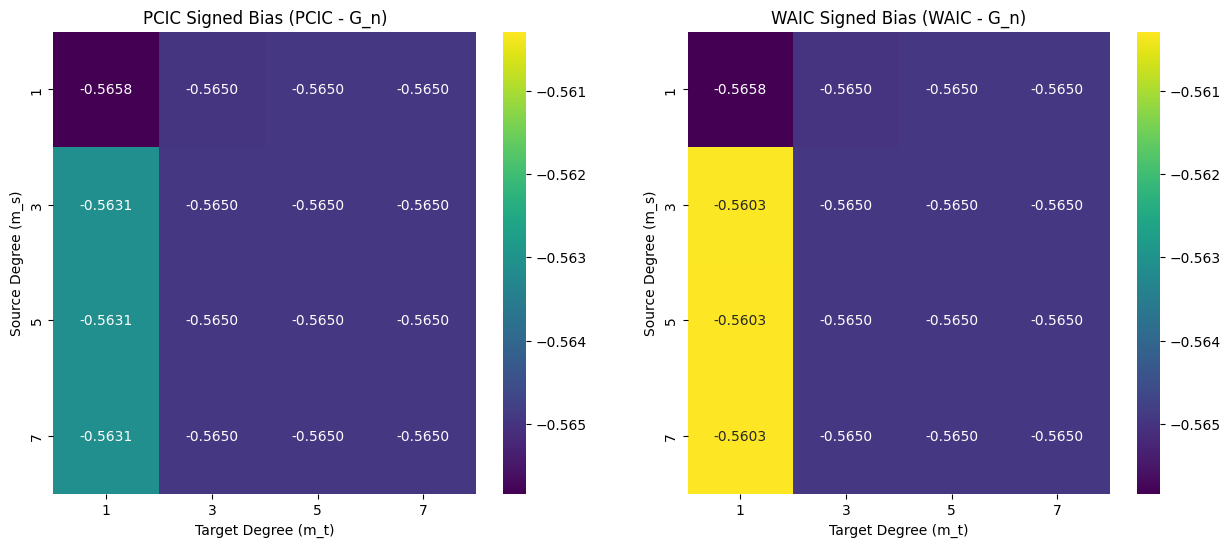

In [9]:
# --- Plotting ---
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

vmin = min(pcic_biases.min(), waic_biases.min())
vmax = max(pcic_biases.max(), waic_biases.max())

kwargs = dict(
    xticklabels=odd_degrees, yticklabels=odd_degrees,
    annot=True, fmt=".4f", cmap="viridis",
    vmin=vmin, vmax=vmax
)

sns.heatmap(pcic_biases, ax=axes[0], **kwargs)
axes[0].set_title("PCIC Signed Bias (PCIC - G_n)")
axes[0].set_xlabel("Target Degree (m_t)")
axes[0].set_ylabel("Source Degree (m_s)")

sns.heatmap(waic_biases, ax=axes[1], **kwargs)
axes[1].set_title("WAIC Signed Bias (WAIC - G_n)")
axes[1].set_xlabel("Target Degree (m_t)")
axes[1].set_ylabel("Source Degree (m_s)")


plt.show()